# 4. Surface reconstruction: joint vs. single-channel

Inversion follows the paper's Section 3: GMRF-regularized MAP estimation of
the surface coefficients, with the inclination estimated by a profile
objective. The prior precision grows with degree,
$q_l = (l/\mathrm{scale})^\alpha$, shrinking poorly-constrained
high-frequency structure.

$$ \hat{\mathbf{s}} = \arg\min_\mathbf{s}
   \|D(\beta)\mathbf{s} - \mathbf{y}\|^2 +
   \lambda\, \mathbf{s}^H Q\, \mathbf{s} $$

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jittermap as jm


In [2]:
L, N = 10, 100
INC_TRUE = 0.6
times = np.linspace(0, 2*np.pi, N, endpoint=False)
s_true = jm.multispot_surface([(30, 315, 18.0), (-15, 30, 13.0)], L,
                              texture_amplitude=0.002, texture_seed=3)
fm = jm.ForwardModel(times, l_max=L)
y = fm.observe(s_true, inclination=INC_TRUE, channels="xyp", stacked=False)

## Noiseless reconstructions

Reconstruct from all channels jointly, then from astrometry alone and
photometry alone. The inclination is estimated in each case.

Joint      : estimated inclination 0.588 (true 0.6)


Astrometry : estimated inclination 0.484 (true 0.6)


Photometry : estimated inclination 0.426 (true 0.6)


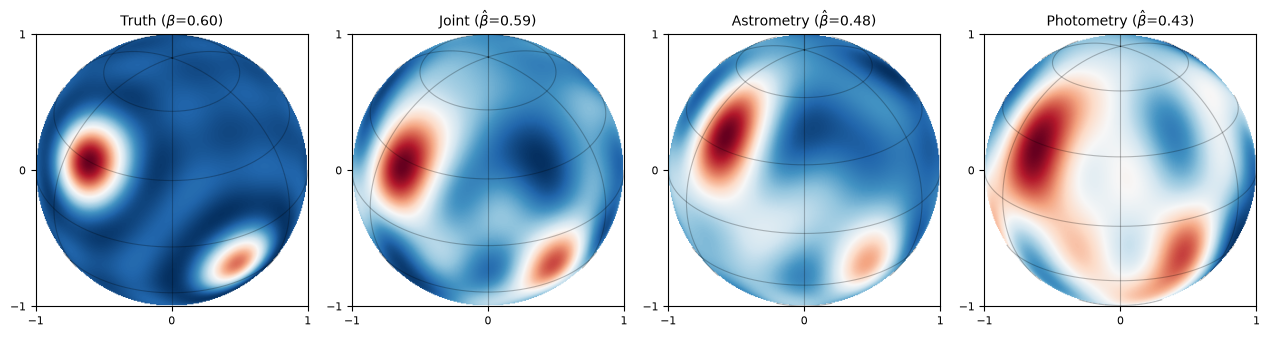

In [3]:
from jittermap.plotting.panels import comparison_figure

results = {}
for label, ch in [("Joint", "xyp"), ("Astrometry", "xy"), ("Photometry", "p")]:
    res = jm.reconstruct({c: y[c] for c in ch}, times, L, channels=ch,
                         lam=2e-4, model=fm)
    results[label] = res
    print(f"{label:11s}: estimated inclination {res.inclination:.3f} "
          f"(true {INC_TRUE})")
fig, _ = comparison_figure(s_true, results, l_true=L, inc_true=INC_TRUE)

Photometry alone misplaces the inclination and smears the spots in latitude
(the light-curve inversion degeneracy); astrometry alone recovers the
odd-degree structure; the joint fit recovers both the surface and the
inclination. This is the paper's central demonstration.

## Noise and regularization

With noisy data the regularization strength $\lambda$ matters. jittermap's
`default_lambda(snr, l_max)` implements the schedule tuned for the paper's
reconstruction gallery — more smoothing at low SNR and for high-degree
fits.

Text(0.5, 1.02, 'SNR = 10')

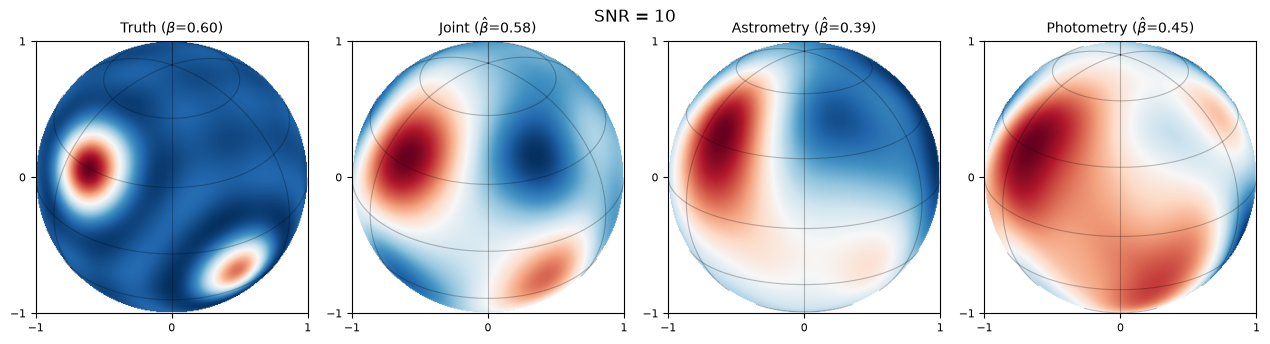

In [4]:
rng = np.random.default_rng(42)
snr = 10
results_snr = {}
for label, ch in [("Joint", "xyp"), ("Astrometry", "xy"), ("Photometry", "p")]:
    y_noisy = {}
    for c in ch:
        sig = np.std(y[c]) * np.sqrt(N) / snr / np.sqrt(N)
        y_noisy[c] = y[c] + rng.normal(0, sig, N)
    res = jm.reconstruct(y_noisy, times, L, channels=ch,
                         snr_total=snr, model=fm)   # lambda from schedule
    results_snr[label] = res
fig, _ = comparison_figure(s_true, results_snr, l_true=L, inc_true=INC_TRUE)
fig.suptitle(f"SNR = {snr}", y=1.02)

## What is recoverable: the identifiable subspace

Even jointly and noiselessly, the design matrix has a null space (the CRB
over the full coefficient vector is unbounded). The MAP estimate recovers
the projection of the truth onto the row space of $D$; the GMRF prior fills
the null space with the smoothest consistent choice.

In [5]:
D = fm.design(INC_TRUE, channels="xyp", stacked=True)
_, sv, Vh = np.linalg.svd(D, full_matrices=False)
rank = int(np.sum(sv > sv[0]*1e-10))
print(f"design matrix: {D.shape}, numerical rank {rank} "
      f"of {D.shape[1]} coefficients")
P = Vh[:rank].conj().T @ Vh[:rank]
err_obs = np.linalg.norm(P @ (results['Joint'].s_hat - s_true))
print(f"error on the identifiable subspace (noiseless joint): {err_obs:.2e}")

design matrix: (300, 121), numerical rank 54 of 121 coefficients
error on the identifiable subspace (noiseless joint): 9.30e-02
